# Extra Exercise

CSO Projected birth-rates in Ireland.  
Author: Orla Woods

## Task 1: Projected birth-rates in Ireland

### Read in the data and examine 

In [12]:
# Import modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
%matplotlib notebook

# Matplotlib.pyplot to display the plots in the ipynb
%matplotlib inline

# To allow animation via matplotlib.pyplot in a ipynb
from IPython.display import HTML

# Import csv file
# https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html
# https://www.datacamp.com/tutorial/pandas-read-csv?utm_cid=19589720821&utm_aid=157156375191&utm_campaign=230119_1-ps-other~dsa~tofu_2-b2c_3-emea_4-prc_5-na_6-na_7-le_8-pdsh-go_9-nb-e_10-na_11-na&utm_loc=9040164-&utm_mtd=-c&utm_kw=&utm_source=google&utm_medium=paid_search&utm_content=ps-other~emea-en~dsa~tofu~tutorial~python&gad_source=1&gad_campaignid=19589720821&gbraid=0AAAAADQ9WsExl9xVUaqHso9VRPl3c2CiA&gclid=CjwKCAjwxrLHBhA2EiwAu9EdM21A8U5l566klHEuLUr8VHiTdFfweCVbX5A5-vkQRVvKZzv2PU5xLBoCOfYQAvD_BwE

# Read the csv file
birthrates = pd.read_csv('cso_birthrates.csv')

# Vview the first 5 rows of the dataframe (sanity check)
birthrates.head()


,Statistic Label,Year,Sex,Criteria for Projection,UNIT,VALUE
0,Projected Annual Births,2023,Both sexes,Method - M1,Number,57537
1,Projected Annual Births,2024,Both sexes,Method - M1,Number,55528
2,Projected Annual Births,2025,Both sexes,Method - M1,Number,55292
3,Projected Annual Births,2026,Both sexes,Method - M1,Number,55032
4,Projected Annual Births,2027,Both sexes,Method - M1,Number,54462


### Check for missing data before plotting

In [13]:
# I tried the following code suggested by co-pilot but the out put is too large (shows full df with # "False" in each value position).
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isna.html

# Check for missing values
# print(birthrates.isna()) # commented out as I don't want to use this

In [14]:
# Try .isna().sum() to get a summary of missing values in each column
# https://www.datacamp.com/tutorial/python-nan-missing-values-in-python
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isna.html

print(birthrates.isna().sum())

Statistic Label            0
Year                       0
Sex                        0
Criteria for Projection    0
UNIT                       0
VALUE                      0
dtype: int64


*Note*: I can now proceed to plot easily as I don't have to deal with missing values.

### Plot projected birth-rates

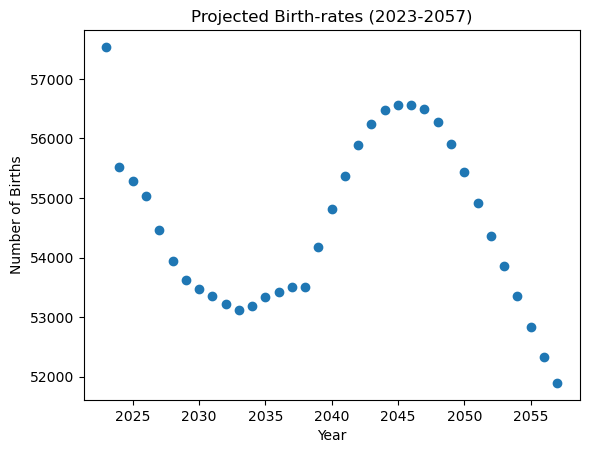

In [15]:
# First, use scatter plot to have a look at the data
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html
# https://chatgpt.com/share/68ecc56e-3da8-800d-b992-21c18cabc982

x = birthrates['Year']
y = birthrates['VALUE']

plt.scatter(x, y)
plt.xlabel('Year')
plt.ylabel('Number of Births')
plt.title('Projected Birth-rates (2023-2057)')
plt.show()


*Note:* I don't think a scatter plot is the best way to present birth-rates. I think a [line plot](https://matplotlib.org/stable/gallery/lines_bars_and_markers/simple_plot.html) will be better so will do this.

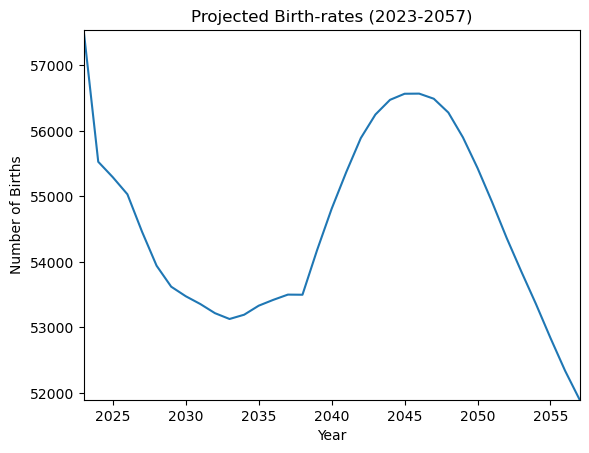

In [16]:
# Define data I want to use 
years = birthrates['Year']
births = birthrates['VALUE']

# Set up the figure and axis
# https://matplotlib.org/stable/gallery/lines_bars_and_markers/simple_plot.html 
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html
fig, ax = plt.subplots()
ax.plot(years, births)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Births')
ax.set_title('Projected Birth-rates (2023-2057)')

# Axis limits
ax.set_xlim(years.min(), years.max())
ax.set_ylim(births.min(), births.max())

# Show
plt.show()

*Note:* I like this but researching, I found this [plot](https://ourworldindata.org/grapher/number-of-births-per-year?time=earliest..2100). To see if I can do it, as an add on for myself, I want to try to use an animation as it is a lovely way to present birth-rates over time. 
The code in that link is too difficult for me to understand (I copied it in and started to try it but
found it too difficult) so I am going to use a line plot and insert animation.
I asked chatgpt how to do this [(link to chat)](https://chatgpt.com/share/69333120-66f0-800d-9602-dbf98c6ebeb1)

In [17]:
# Use an animation to show how birthrates are projected to change over time
# https://matplotlib.org/stable/api/animation_api.html
# Taking the chatGPT conversation as reference: 
# (https://chatgpt.com/share/69333120-66f0-800d-9602-dbf98c6ebeb1)

# Define data I want to use and convert to numpy arrays
years = birthrates['Year'].to_numpy()
births = birthrates['VALUE'].to_numpy()

# Set up the figure and axis
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Births')
ax.set_title('Projected Birth-rates (2023-2057)')

# Initialise an empty line
line, = ax.plot([], [], 'o-', lw=2, color="cyan")

# Axis limits
ax.set_xlim(years.min(), years.max())
ax.set_ylim(births.min(), births.max())

# Update the function for animation
def update(frame):
    line.set_data(years[:frame], births[:frame])
    return line,    

# Create the animation and use blit=False for stabililty
ani = FuncAnimation(fig, update, frames=len(years)+1, interval=200, blit =False)

# Prevent Jupyter from drawing a blank static figure
plt.close(fig)

# Display the animation inline without changing the backend
HTML(ani.to_jshtml())

*Note:* I really like the look of this so will move on.

## Task 2: Population by age

### Read in the csv file and examine

In [18]:
# read the csv file
popbyage = pd.read_csv('popbyage.csv')

# view the first 5 rows of the dataframe
popbyage.head()

,Statistic Label,CensusYear,Sex,Single Year of Age,Administrative Counties,UNIT,VALUE
0,Population,2022,Both sexes,All ages,Ireland,Number,5149139
1,Population,2022,Both sexes,All ages,Carlow County Council,Number,61968
2,Population,2022,Both sexes,All ages,Dublin City Council,Number,592713
3,Population,2022,Both sexes,All ages,Dún Laoghaire Rathdown County Council,Number,233860
4,Population,2022,Both sexes,All ages,Fingal County Council,Number,330506


### Check for missing data

In [19]:
# Try .isna().sum() to get a summary of missing values in each column
# https://www.datacamp.com/tutorial/python-nan-missing-values-in-python
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isna.html

print(popbyage.isna().sum())

Statistic Label            0
CensusYear                 0
Sex                        0
Single Year of Age         0
Administrative Counties    0
UNIT                       0
VALUE                      0
dtype: int64


### Plot Population by age at a National Level: Line Plot

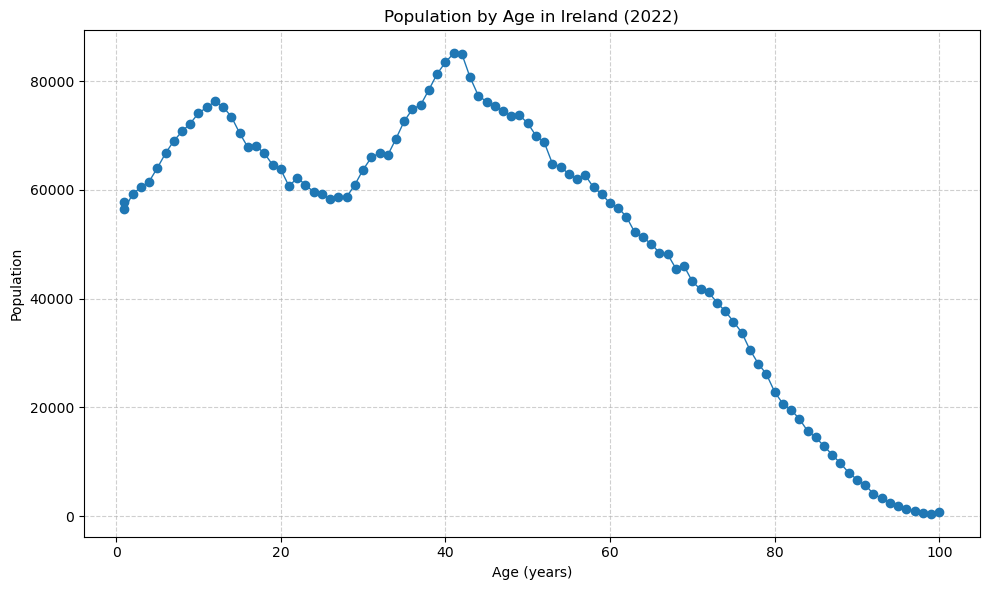

In [20]:
# Scatter plot looks awful with so many datapoints on the x-axis (single years).
# Similarly, histogram not suitable, line plot not suitable. 
# Try line plot instead
# Using converstion with chatgpt to then change for my imported csv data, as above
# https://chatgpt.com/share/68ed41d0-21c0-800d-acb0-cf9efe19a90f

# Line plot
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html

# Population by age, national level
# Filter for national total
ireland = popbyage[(popbyage["Administrative Counties"] == "Ireland") &
             (popbyage["Sex"] == "Both sexes") &
             (popbyage["Single Year of Age"] != "All ages")]

# Add .copy() to avoid SettingWithCopyWarning
ireland = ireland.copy()

# Convert 'VALUE' to numeric
ireland["VALUE"] = pd.to_numeric(ireland["VALUE"], errors="coerce")

# Clean 'Single Year of Age' (e.g. "Under 1 year" -> 0)
ireland["Age"] = ireland["Single Year of Age"].str.extract(r"(\d+)").fillna(0).astype(int)

# Plot
plt.figure(figsize=(10,6))
plt.plot(ireland["Age"], ireland["VALUE"], marker='o', linewidth=1)
plt.title("Population by Age in Ireland (2022)")
plt.xlabel("Age (years)")
plt.ylabel("Population")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

*Note:* This was an interesting exercise to think about what you can and can't do with a huge datasaet with many variables. Interesting to see that the best thing is probably not to try to show everything but instead to dive into the data and give different perspectives. For this reason I will now (taking ChatGPT's advice) try to view the data by county. 

### Plot Population by Age and County: Heatmap

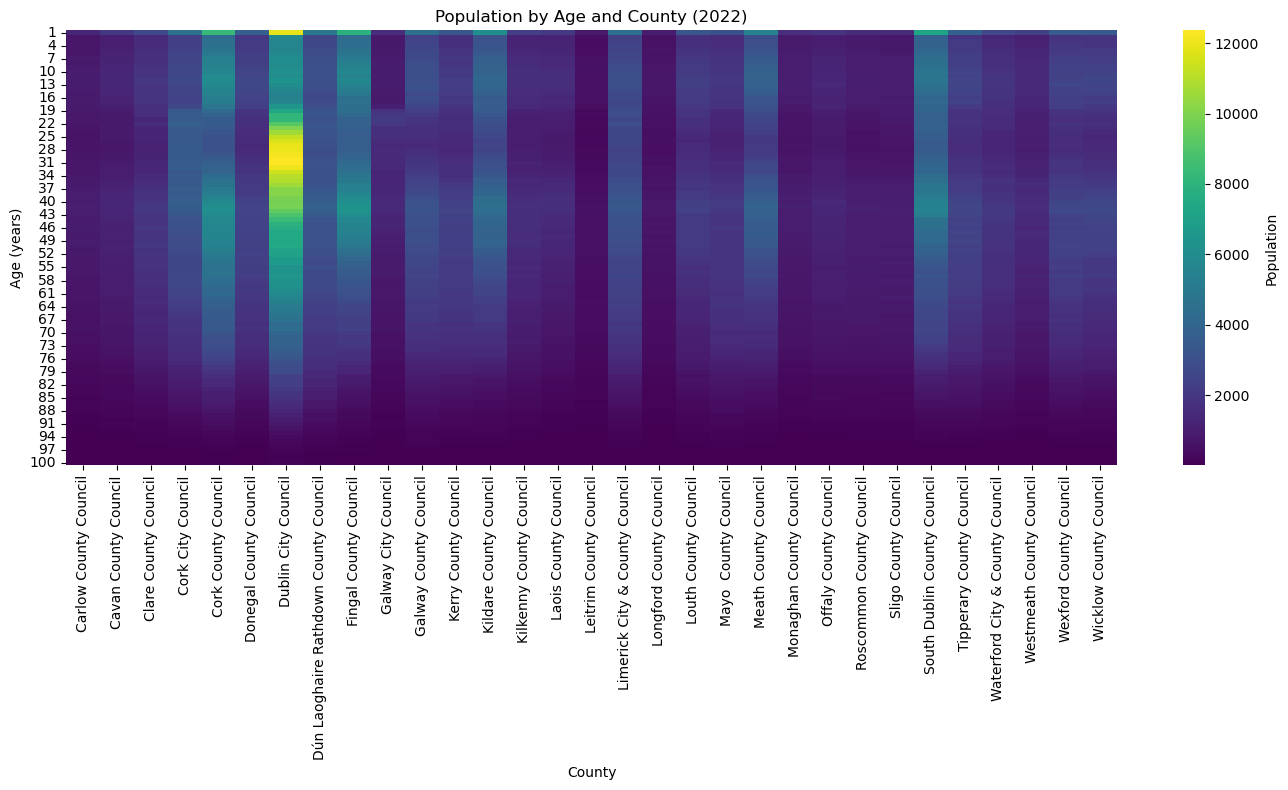

In [21]:
# Following the same conversation with ChatGPT, plot a heatmap
#  https://seaborn.pydata.org/generated/seaborn.heatmap.html

import seaborn as sns

subset = popbyage[
    (popbyage["Sex"] == "Both sexes") &
    (popbyage["Administrative Counties"] != "Ireland") &
    (popbyage["Single Year of Age"] != "All ages")
].copy()  # added .copy() to avoid SettingWithCopyWarning

subset["VALUE"] = pd.to_numeric(subset["VALUE"], errors="coerce")
subset["Age"] = subset["Single Year of Age"].str.extract(r"(\d+)").fillna(0).astype(int)

# Use pivot_table with an aggregation function to handle duplicates
pivot = subset.pivot_table(
    index="Age",
    columns="Administrative Counties",
    values="VALUE",
    aggfunc="sum"  # replaces pivot(), ensures one value per cell
)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot, cmap="viridis", cbar_kws={'label': 'Population'})
plt.title("Population by Age and County (2022)")
plt.xlabel("County")
plt.ylabel("Age (years)")
plt.tight_layout()
plt.show()